- uncomment to install library

In [1]:
#! pip install pydot

In [2]:
#! pip install graphviz 

## Setup Experiment

- set parameter

In [1]:
labels = ['AF', 'N']

fs = 250

feature_type = "vgg16" # ubah ke 'vgg16', 'resnet50', 'densenet121'

threshold_acc = 0.98

use_merge_split = True

reduce_float_size = True

test_size_split=0.1

EPOCHS = 16

BATCH_SIZE = 128

In [2]:
import os
import datetime

experiment_folder = "experiment/"

experiment_name = feature_type + "_" + datetime.datetime.now().strftime("%Y_%m_%d__%H_%M_%S")

if not os.path.exists(experiment_folder + experiment_name) :
    os.mkdir(experiment_folder + experiment_name)

In [3]:
dataset_folder = 'dataset/'

filenames = []
for filename in os.listdir(dataset_folder):
    if filename.find(".npz") > -1 or filename.find("_all") > -1:
        filenames.append(filename)

In [4]:
filenames

['test_all.csv',
 'test_all_Conv_AE.csv',
 'test_vgg16_feature.npz',
 'test_y.npz',
 'train_all.csv',
 'train_all_Conv_AE.csv',
 'train_vgg16_feature.npz',
 'train_y.npz']

In [5]:

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# from keras.utils.np_utils import to_categorical

Using TensorFlow backend.


## Load dataset

- load target data (y_train, y_test)

In [27]:
y_train = np.load(dataset_folder + 'train_y.npz')['y']
y_test = np.load(dataset_folder + 'test_y.npz')['y']

# y_train = to_categorical(y_train)
# y_test = to_categorical(y_test)

- load feature data

In [29]:
X_train = []
X_test = []

if feature_type == "vgg16" :
    X_train = np.load(dataset_folder + 'train_vgg16_feature.npz')['vgg16_feature']
    X_test = np.load(dataset_folder + 'test_vgg16_feature.npz')['vgg16_feature']
    
elif feature_type == "resnet50" :
    X_train = np.load(dataset_folder + 'train_resnet50_feature.npz')['resnet50_feature']
    X_test = np.load(dataset_folder + 'test_resnet50_feature.npz')['resnet50_feature']
    
elif feature_type == "densenet121" :
    X_train = np.load(dataset_folder + 'train_densenet121_feature.npz')['densenet121_feature']
    X_test = np.load(dataset_folder + 'test_densenet121_feature.npz')['densenet121_feature']
    
else :
    raise("feature %s not found!" % feature_type)

In [30]:
X_train = np.squeeze(X_train)
X_test = np.squeeze(X_test)

In [31]:
y_train.shape, X_train.shape, y_test.shape, X_test.shape

((51000, 2), (51000, 7, 7, 512), (9000, 2), (9000, 7, 7, 512))

In [32]:
if reduce_float_size:
    X_train = X_train.astype(np.float16)
    X_test = X_test.astype(np.float16)

## Merging & Splitting

- merging feature data & target data

In [33]:
X = []
y = []
    
if use_merge_split :
    y = np.vstack((y_train, y_test))
    X = np.vstack((X_train, X_test))
    
    print(y.shape, X.shape)
    X_train = []
    X_test = []
    y_train = []
    y_test= []

(60000, 2) (60000, 7, 7, 512)


In [34]:
if use_merge_split :
    print( "X size : %.2f GB" % (X.nbytes/1024/1024/1024))
    print( "y size : %.2f MB" % (y.nbytes/1024/1024))

X size : 2.80 GB
y size : 0.46 MB


In [35]:
if use_merge_split :
    unique, counts = np.unique(y, return_counts=True)

    print(dict(zip([labels[int(i)] for i  in unique], counts)))

{'AF': 60000, 'N': 60000}


- splitting data (15% test)

In [36]:
if use_merge_split :
    
    X_train, X_test, y_train, y_test = train_test_split(
                                        X, y, test_size=test_size_split, random_state=42)
    
    print(y_train.shape, X_train.shape, y_test.shape, X_test.shape)
    
    X = []
    y = []

(54000, 2) (54000, 7, 7, 512) (6000, 2) (6000, 7, 7, 512)


## Utils Function

In [38]:
import json

def readJson_config(Path, Name, Key):
    with open(Path + Name) as json_config:
        json_object = json.load(json_config)

    return json_object[Key]


def writeJson_config(Path, Name, Data, append):
    mode = 'a+' if append else 'w'
    full_path = Path + Name

    with open(full_path, mode=mode) as json_config:
        json.dump(Data, json.load(json_config) if append else json_config)
    
    return 'success' 


In [39]:
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(5, 5))
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    
    plt.savefig(experiment_folder + experiment_name +
               "/plot-confusion-matrix-%s.png" % feature_type)
    
    plt.show()

In [40]:
def evaluate_model(history):
    
    fig1, ax_acc = plt.subplots()
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Model - Accuracy')
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.grid()
    plt.show()
    fig1.savefig(experiment_folder + experiment_name +
               "/plot-accuracy-%s.png" % feature_type)
    
    fig2, ax_loss = plt.subplots()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Model- Loss')
    plt.legend(['Training', 'Validation'], loc='upper right')
    plt.grid()
    plt.show()
    fig2.savefig(experiment_folder + experiment_name +
               "/plot-loss-%s.png" % feature_type)

## Building Convolutional Neural Network

- Import Keras library

In [41]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from keras.layers import Input
from keras.layers.normalization import BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.utils import plot_model

import keras

- Buat CNN Model dengan aritektur network : 
`CONV-POOL-CONV-POOL-CONV-POOL-FC`
- CONV : 1D Convolutional Layer
- POOL : MAX Pooling Layer
- FC   : Dense Layer + Activation

In [42]:
def cnn_model(input_shape):
    
    model = Sequential()
    
    model.add(Conv2D(filters=128,
                     kernel_size=3,
                     activation='relu',
                     input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=64,
                     kernel_size=3,
                     activation='relu',
                     input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=2,
                        strides=2,
                        padding='same'))
    

    # Fully Connected layer (FC)
    model.add(Flatten())
    model.add(Dense(256, 
                    activation='relu'))
    model.add(Dense(64, 
                    activation='relu'))
    model.add(Dense(2, 
                    activation='softmax'))
              
    model.summary()
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy',
                  metrics = ['accuracy'])

    return model

- sekarang kita akan melakukan proses training model dengan memanfaatkan `.fit()` pada model yang kita buat diatas.
- selain itu kita gunakan juka teknik `EarlyStoping()` untuk menghentikan proses training jika terjadi divergensi pada validation data yang diakibatkan oleh overfitting. 
- pada `EarlyStoping()` kita gunakan parmeter `patience=8` yang artinya jika proses training untuk 8 epoch tidak terjadi peningkatan maka hentikan proses training.

In [43]:
def check_model(model_, x, y, x_test, y_test, epochs_, batch_size_):
    callbacks = [EarlyStopping(monitor='val_loss', patience=3),
                 ModelCheckpoint(filepath='cnn_classif_best_model.h5', monitor='val_loss', save_best_only=True)]

    hist = model_.fit(x, 
                      y,
                      epochs=epochs_,
                      callbacks=callbacks, 
                      batch_size=batch_size_,
                      shuffle=True,
                      #validation_split=0.15)
                      validation_data=(x_test, y_test))
    #model_.load_weights('cnn_classif_best_model.h5')
    return hist 

### Train Model CNN

- jalankan proses training dengan `EPOCH` sebanyak 16 dan `BATCH_SIZE` sebesar 32

In [44]:
input_shape = X_train[0].shape

model = cnn_model(input_shape)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 5, 5, 128)         589952    
_________________________________________________________________
batch_normalization_3 (Batch (None, 5, 5, 128)         512       
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 3, 3, 64)          73792     
_________________________________________________________________
batch_normalization_4 (Batch (None, 3, 3, 64)          256       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 2, 2, 64)          0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 256)               0         
_________________________________________________________________
dense_4 (Dense)              (None, 256)               65792     
__________

- Save model arhitecture

In [45]:
with open(experiment_folder + experiment_name +
              '/model_summary_%s.txt' % feature_type, 'w') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))

- Train model

In [46]:
history=check_model(model, X_train, y_train, X_test, y_test, EPOCHS, BATCH_SIZE)

Train on 54000 samples, validate on 6000 samples
Epoch 1/16
54000/54000 [==============================] - 76s 1ms/step - loss: 0.2046 - acc: 0.9170 - val_loss: 0.1961 - val_acc: 0.9172
Epoch 2/16
54000/54000 [==============================] - 43s 805us/step - loss: 0.1106 - acc: 0.9579 - val_loss: 0.1159 - val_acc: 0.9575
Epoch 3/16
54000/54000 [==============================] - 45s 840us/step - loss: 0.0756 - acc: 0.9718 - val_loss: 0.0953 - val_acc: 0.9653
Epoch 4/16
54000/54000 [==============================] - 46s 845us/step - loss: 0.0545 - acc: 0.9801 - val_loss: 0.0878 - val_acc: 0.9667
Epoch 5/16
54000/54000 [==============================] - 46s 849us/step - loss: 0.0442 - acc: 0.9837 - val_loss: 0.0840 - val_acc: 0.9738
Epoch 6/16
54000/54000 [==============================] - 47s 863us/step - loss: 0.0333 - acc: 0.9875 - val_loss: 0.0947 - val_acc: 0.9702
Epoch 7/16
54000/54000 [==============================] - 46s 857us/step - loss: 0.0293 - acc: 0.9897 - val_loss: 0.080

- Save model binary

In [47]:
model.save(experiment_folder + experiment_name + "/CNN_Classification_model_%s.h5" % feature_type)

- save model training history (log)

In [48]:
pd.DataFrame.from_dict(history.history).to_csv( experiment_folder + experiment_name +
                                               '/history_train_CNN_feature_%s.csv' % feature_type, index=False)

# Evaluate Model

- Plot Accuracy vs Epochs
- Plot Loss vs Epochs

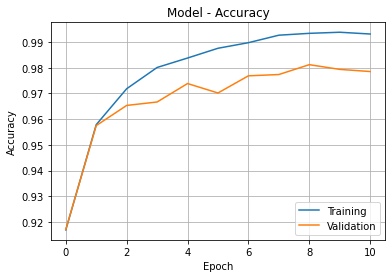

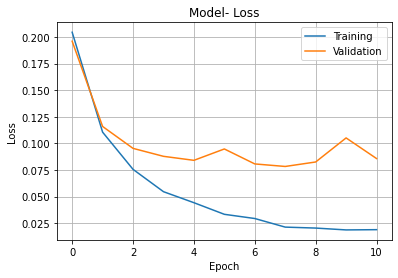

In [49]:
evaluate_model(history)    

- Plot Confusion Matrix

In [50]:
# predict test data
y_pred=model.predict(X_test)

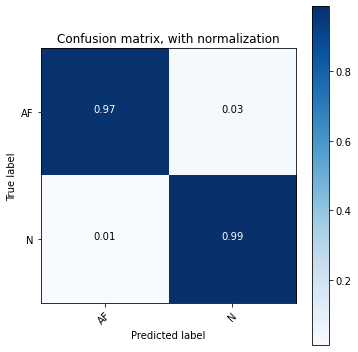

In [51]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1))
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plot_confusion_matrix(cnf_matrix, classes=['AF', 'N'],normalize=True,
                      title='Confusion matrix, with normalization')

- dari hasil plot confusion matrix, dapat dilihat tiap kelas memiliki banyak TRUE POSITIVE predicted data
- semakin gelap kebiruan menunjukan banyaknya hasil predicted label untuk true label tersebut

- Plot Classification Report

In [52]:
print(classification_report(y_test.argmax(axis=1), 
                            y_pred.argmax(axis=1), 
                            target_names=['AF', 'N']))

              precision    recall  f1-score   support

          AF       0.99      0.97      0.98      3001
           N       0.97      0.99      0.98      2999

    accuracy                           0.98      6000
   macro avg       0.98      0.98      0.98      6000
weighted avg       0.98      0.98      0.98      6000



- Jika kita lihat, nilai report untuk seluruh klas juga bagus, 
- Nilai recall dan precission juga tinggi, menunjukan model mampu memprediksi data dengan baik untuk seluruh data pada sclass tersebut 

- save report

In [53]:
report_dict = classification_report(y_test.argmax(axis=1), 
                            y_pred.argmax(axis=1), 
                            target_names=['AF', 'N'],
                            output_dict=True)

writeJson_config(experiment_folder + experiment_name + "/", 
                 "report-%s.json" % feature_type, report_dict, False)

'success'

- save model spec

In [54]:
model_spec_dict = {}
model_spec_dict['train_size'] = [y_train.shape, X_train.shape]
model_spec_dict['test_size'] =  [y_test.shape, X_test.shape]
model_spec_dict['epoch'] =  EPOCHS
model_spec_dict['batch_size'] =  BATCH_SIZE
model_spec_dict['use_merge_split'] =  use_merge_split
model_spec_dict['reduce_float_size'] = reduce_float_size
model_spec_dict['test_size_split'] = test_size_split

writeJson_config(experiment_folder + experiment_name + "/", 
                 "model-spec-%s.json" % feature_type, model_spec_dict, False)

'success'

- Update Experiment Header

In [55]:
with open(experiment_folder + 
              '/experiment_header.txt', 'a') as f:
    f.write("Experiment Name \t: %s \n" % experiment_name)
    f.write("Accuracy \t\t: %.4f\n\n\n" % report_dict['accuracy'])

- move best experiment to main dir (>= threshold accuracy)

In [56]:
if report_dict['accuracy'] >= threshold_acc:
    import shutil
    
    shutil.copy(experiment_folder + experiment_name + "plot-accuracy-vgg16.png", "5. plot-accuracy-vgg16.png")
    shutil.copy(experiment_folder + experiment_name + "plot-loss-vgg16.png", "5. plot-loss-vgg16.png")
    shutil.copy(experiment_folder + experiment_name + "plot-confusion-matrix-vgg16.png", "5. plot-confusion-matrix-vgg16.png")
    shutil.copy(experiment_folder + experiment_name + "history_train_CNN_feature_vgg16.csv", "history_train_CNN_feature_vgg16.csv")
    shutil.copy(experiment_folder + experiment_name + "report-vgg16.json", "classification-report-vgg16.json")
    shutil.copy(experiment_folder + experiment_name + "CNN_Classification_model_vgg16.h5", "CNN_Classification_model_vgg16.h5")
    print("[INFO] success move best result to main dir!")
else :
    print("[INFO] accuracy %.4f, is under threshold !" % report_dict['accuracy'])

[INFO] accuracy 0.9785, is under threshold !
